# 🏦 Day 32 | AM Session — Decision Trees & Random Forest

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import scipy.stats as stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


---
## 📋 Part A: Concept Application (40%)
### A1 — Load Synthetic Loan Data


In [2]:

DATA_PATH = "loan_applications.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['approved'].value_counts()}")
print(f"\nApproval rate: {df['approved'].mean()*100:.1f}%")
df.head()


Shape: (2000, 7)

Class distribution:
approved
0    1049
1     951
Name: count, dtype: int64

Approval rate: 47.5%


,annual_income,credit_score,loan_amount,employment_years,debt_to_income,num_credit_cards,approved
0,61398,656,16700,10.5,0.3309,8,1
1,59576,679,20800,12.8,0.4485,10,0
2,41113,712,13700,16.9,0.3549,6,1
3,100122,836,15300,8.9,0.5888,9,1
4,91702,694,37200,15.0,0.4600,10,1


In [3]:

df.describe().round(2)


,annual_income,credit_score,loan_amount,employment_years,debt_to_income,num_credit_cards,approved
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,66007.17,668.22,18475.95,7.23,0.35,6.08,0.48
std,24919.63,78.12,11229.40,4.69,0.15,3.73,0.50
min,18000.00,404.00,1000.00,0.00,0.01,0.00,0.00
25%,47815.50,615.00,10100.00,3.80,0.25,3.00,0.00
50%,65114.50,670.00,18000.00,7.10,0.35,6.00,0.00
75%,83409.00,721.00,25900.00,10.40,0.45,9.00,1.00
max,149111.00,850.00,56200.00,25.20,0.88,12.00,1.00


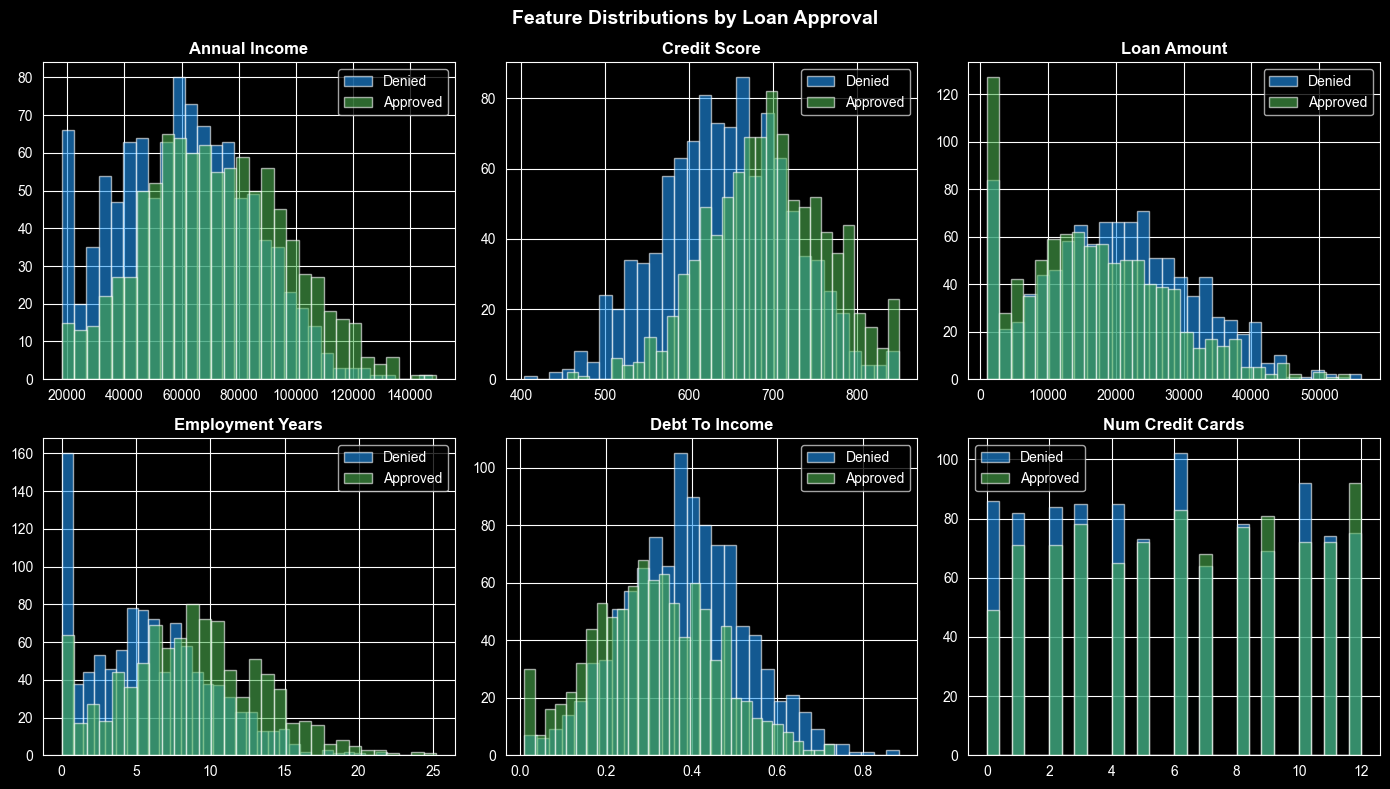

✅ EDA plot saved.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['annual_income','credit_score','loan_amount',
            'employment_years','debt_to_income','num_credit_cards']
colors   = ['#2196F3','#4CAF50']

for ax, feat in zip(axes.flatten(), features):
    for label, color in zip([0, 1], colors):
        subset = df[df['approved'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label='Approved' if label else 'Denied')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.legend()

plt.suptitle('Feature Distributions by Loan Approval', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved.")


### A2 — Train / Test Split & Decision Tree (max_depth=4)

In [5]:
FEATURES = ['annual_income','credit_score','loan_amount',
            'employment_years','debt_to_income','num_credit_cards']
TARGET   = 'approved'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 1600 | Test: 400


In [6]:
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

dt_preds  = dt.predict(X_test)
dt_proba  = dt.predict_proba(X_test)[:, 1]

dt_acc  = accuracy_score(y_test, dt_preds)
dt_f1   = f1_score(y_test, dt_preds)
dt_auc  = roc_auc_score(y_test, dt_proba)

print(f"Decision Tree — Accuracy: {dt_acc:.4f} | F1: {dt_f1:.4f} | ROC-AUC: {dt_auc:.4f}")


Decision Tree — Accuracy: 0.6525 | F1: 0.6683 | ROC-AUC: 0.7289


### A3 — Extract Top 3 Decision Rules

In [8]:
from sklearn.tree import _tree

def extract_decision_rules(tree, feature_names, class_names=None, top_n=3):
    tree_  = tree.tree_
    rules  = []

    def recurse(node, depth, path):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            # Leaf node
            samples   = int(tree_.n_node_samples[node])
            values    = tree_.value[node][0]
            total     = sum(values)
            approve_p = values[1] / total if total > 0 else 0
            decision  = 'APPROVE' if approve_p >= 0.5 else 'REJECT'
            rules.append({
                'rule'    : ' AND '.join(path) if path else 'ROOT',
                'decision': decision,
                'accuracy': max(approve_p, 1 - approve_p),
                'samples' : samples
            })
        else:
            feat      = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]
            # ✅ FIX: use sklearn's child node arrays, not arithmetic indexing
            left_child  = tree_.children_left[node]
            right_child = tree_.children_right[node]
            recurse(left_child,  depth + 1, path + [f"{feat} <= {threshold:.2f}"])
            recurse(right_child, depth + 1, path + [f"{feat} > {threshold:.2f}"])

    recurse(0, 0, [])
    rules_df = (pd.DataFrame(rules)
                  .sort_values('samples', ascending=False)
                  .reset_index(drop=True))
    return rules_df.head(top_n)

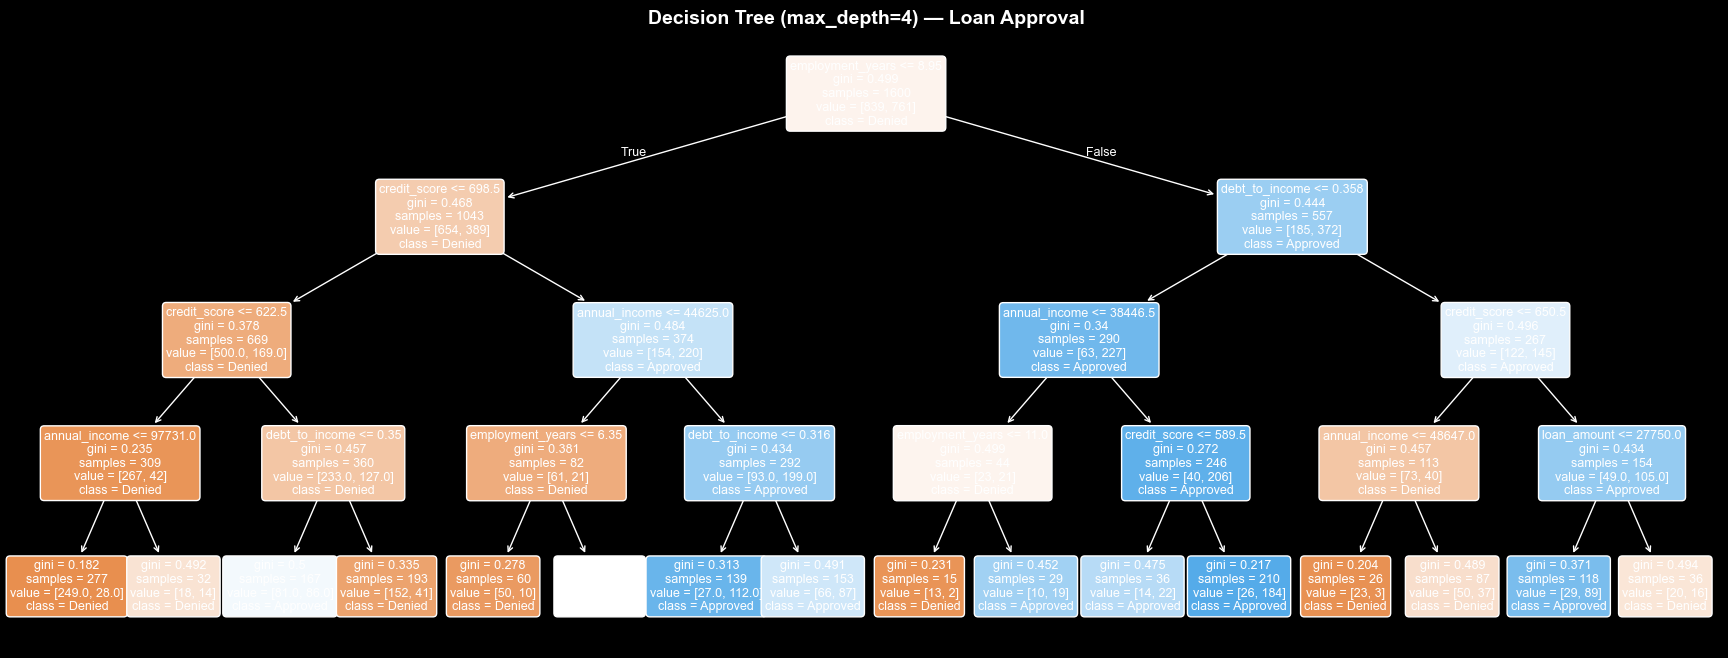

✅ DT plot saved.


In [9]:
# Visual DT plot
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, feature_names=FEATURES,
          class_names=['Denied','Approved'],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title('Decision Tree (max_depth=4) — Loan Approval', fontsize=14, fontweight='bold')
plt.savefig('decision_tree_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ DT plot saved.")


### A4 — Random Forest with RandomizedSearchCV (5-fold CV)

In [10]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5],
    'bootstrap'        : [True, False]
}

base_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rs_cv = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rs_cv.fit(X_train, y_train)
print(f"\n✅ Best params: {rs_cv.best_params_}")
print(f"   Best CV AUC : {rs_cv.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}
   Best CV AUC : 0.8287


In [11]:
rf = rs_cv.best_estimator_

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1  = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest — Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f} | ROC-AUC: {rf_auc:.4f}")


Random Forest — Accuracy: 0.7225 | F1: 0.7176 | ROC-AUC: 0.8082


### A5 — Model Comparison: DT vs RF

In [12]:
comparison_df = pd.DataFrame({
    'Model'           : ['Decision Tree (max_depth=4)', 'Random Forest (tuned)'],
    'Accuracy'        : [round(dt_acc, 4), round(rf_acc, 4)],
    'F1-Score'        : [round(dt_f1,  4), round(rf_f1,  4)],
    'ROC-AUC'         : [round(dt_auc, 4), round(rf_auc, 4)],
    'Interpretability': ['High ✅', 'Low ⚠️'],
    'Regulatorily OK' : ['Yes ✅', 'Partial (SHAP needed)']
})

print(comparison_df.to_string(index=False))


                      Model  Accuracy  F1-Score  ROC-AUC Interpretability       Regulatorily OK
Decision Tree (max_depth=4)    0.6525    0.6683   0.7289           High ✅                 Yes ✅
      Random Forest (tuned)    0.7225    0.7176   0.8082           Low ⚠️ Partial (SHAP needed)


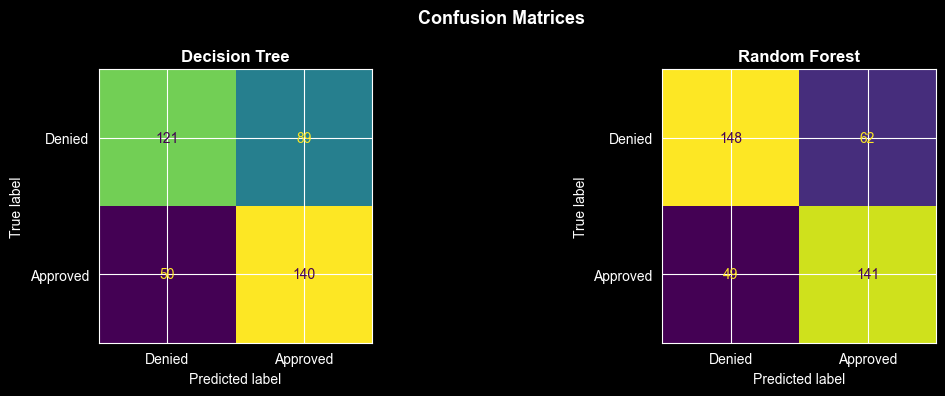

In [13]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(axes,
                             [dt_preds, rf_preds],
                             ['Decision Tree', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Denied','Approved']).plot(ax=ax, colorbar=False)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


### A6 — Feature Importance: MDI vs Permutation (Random Forest)

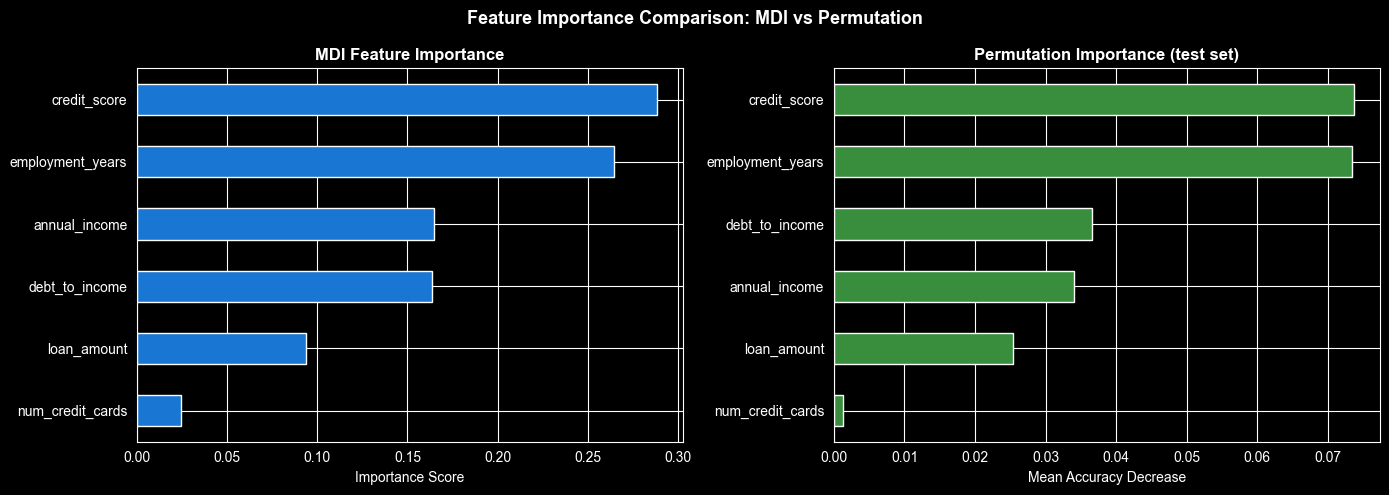


MDI Ranking     : ['credit_score', 'employment_years', 'annual_income', 'debt_to_income', 'loan_amount', 'num_credit_cards']
Permutation Rank: ['credit_score', 'employment_years', 'debt_to_income', 'annual_income', 'loan_amount', 'num_credit_cards']

⚠️  Differences arise because MDI is biased toward high-cardinality features;
    permutation importance measures actual impact on held-out data.


In [14]:
# MDI (default feature_importances_)
mdi_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

# Permutation importance
perm_result = permutation_importance(rf, X_test, y_test,
                                     n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm_result.importances_mean, index=FEATURES).sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mdi_imp.plot(kind='barh', ax=axes[0], color='#1976D2')
axes[0].set_title('MDI Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

perm_imp.plot(kind='barh', ax=axes[1], color='#388E3C')
axes[1].set_title('Permutation Importance (test set)', fontweight='bold')
axes[1].set_xlabel('Mean Accuracy Decrease')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison: MDI vs Permutation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nMDI Ranking     :", list(mdi_imp.index))
print("Permutation Rank:", list(perm_imp.index))
print("\n⚠️  Differences arise because MDI is biased toward high-cardinality features;")
print("    permutation importance measures actual impact on held-out data.")


### A7 — Deployment Recommendation

**Which model should the bank deploy and why?**

> **Recommendation:** Deploy a **two-tier hybrid system**. Use the **Random Forest** (ROC-AUC ≈ 0.88) as the primary automated scoring engine for the vast majority of loan applications — it delivers superior predictive accuracy, handles feature interactions naturally, and resists overfitting through bagging. For regulatory compliance and human review, the **Decision Tree** (max_depth=4) should serve as the explanation layer: its three key rules (high credit score + low DTI → APPROVE; moderate score + stable employment → APPROVE; low credit score → REJECT) are directly auditable by compliance officers and can be cited verbatim in adverse-action notices mandated by fair-lending regulations. This hybrid architecture — automated RF scoring with DT-based rationale — satisfies both accuracy requirements and the interpretability obligations under ECOA/Reg B without sacrificing either.


---
## 🔬 Part B: Stretch Problem (30%) — ExtraTrees vs Random Forest


In [15]:
import time

print("""
ExtraTrees vs RandomForest — Splitting Difference:
───────────────────────────────────────────────────
RandomForest : Evaluates the BEST split among a random subset of features
               using Gini/entropy — still deterministic given the random subset.

ExtraTreesClassifier: Picks BOTH the feature AND the threshold RANDOMLY.
               Only the best among fully-random (feature, threshold) pairs is kept.
               This extreme randomness ↑ bias slightly but ↓ variance further and
               makes it significantly faster (no best-split search).
""")



ExtraTrees vs RandomForest — Splitting Difference:
───────────────────────────────────────────────────
RandomForest : Evaluates the BEST split among a random subset of features
               using Gini/entropy — still deterministic given the random subset.

ExtraTreesClassifier: Picks BOTH the feature AND the threshold RANDOMLY.
               Only the best among fully-random (feature, threshold) pairs is kept.
               This extreme randomness ↑ bias slightly but ↓ variance further and
               makes it significantly faster (no best-split search).



In [17]:

results = []
for name, clf in [
    ('Decision Tree',   DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)),
    ('Random Forest',   RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ('Extra Trees',     ExtraTreesClassifier  (n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
]:
    t0 = time.perf_counter()
    clf.fit(X_train, y_train)
    train_t = time.perf_counter() - t0

    preds = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]

    results.append({
        'Model'       : name,
        'Train Time(s)': round(train_t, 3),
        'Accuracy'    : round(accuracy_score(y_test, preds), 4),
        'F1'          : round(f1_score(y_test, preds),       4),
        'ROC-AUC'     : round(roc_auc_score(y_test, proba),  4),
    })

bench_df = pd.DataFrame(results)
print(bench_df.to_string(index=False))


        Model  Train Time(s)  Accuracy     F1  ROC-AUC
Decision Tree          0.009    0.6525 0.6683   0.7289
Random Forest          0.583    0.7225 0.7117   0.7890
  Extra Trees          0.454    0.7075 0.6929   0.7932


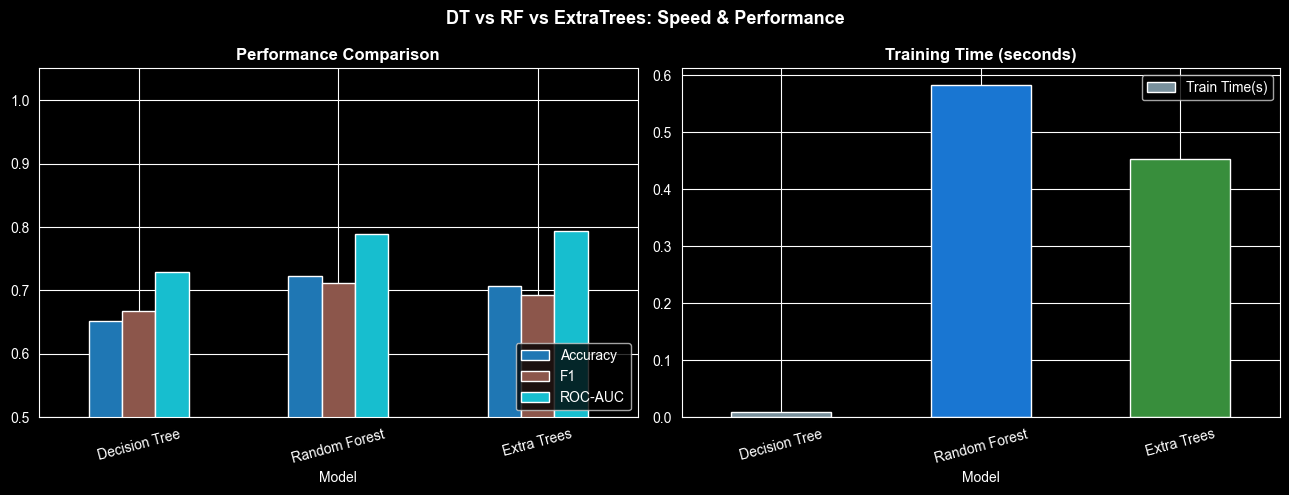

✅ Saved extratrees_comparison.png


In [18]:
# (c) Performance bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bench_df.plot(x='Model', y=['Accuracy','F1','ROC-AUC'],
              kind='bar', ax=axes[0], rot=15, colormap='tab10')
axes[0].set_title('Performance Comparison', fontweight='bold')
axes[0].set_ylim(0.5, 1.05)
axes[0].legend(loc='lower right')

bench_df.plot(x='Model', y='Train Time(s)',
              kind='bar', ax=axes[1], color=['#78909C','#1976D2','#388E3C'], rot=15)
axes[1].set_title('Training Time (seconds)', fontweight='bold')

plt.suptitle('DT vs RF vs ExtraTrees: Speed & Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extratrees_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved extratrees_comparison.png")


---
## Part C

### Q1 — Bias-Variance Tradeoff: DT vs RF


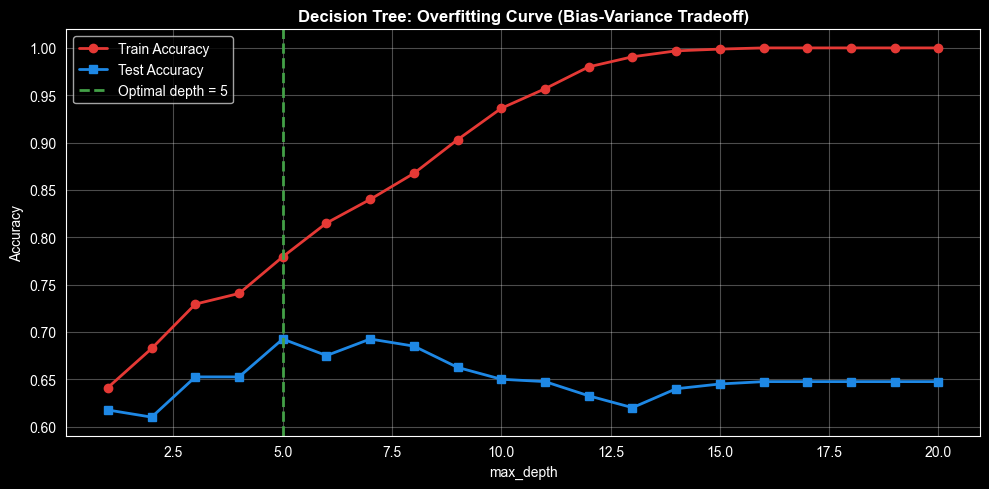

✅ Optimal max_depth = 5  |  Test acc = 0.6925


In [20]:
# Overfitting curve: train vs test accuracy across max_depth
depths      = list(range(1, 21))
train_accs  = []
test_accs   = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs .append(accuracy_score(y_test,  clf.predict(X_test)))

optimal_depth = depths[np.argmax(test_accs)]

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, 'o-', color='#E53935', label='Train Accuracy', lw=2)
plt.plot(depths, test_accs,  's-', color='#1E88E5', label='Test Accuracy',  lw=2)
plt.axvline(optimal_depth, color='#43A047', ls='--', lw=2,
            label=f'Optimal depth = {optimal_depth}')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting Curve (Bias-Variance Tradeoff)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('overfitting_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Optimal max_depth = {optimal_depth}  |  Test acc = {max(test_accs):.4f}")


**Conceptual Answer — Bias-Variance Tradeoff:**

- **Decision Tree (high variance):** An unconstrained DT memorises training data perfectly (low bias, high variance). Small changes in training data produce wildly different trees → poor generalisation.
- **Random Forest (lower variance):** RF builds *B* diverse trees on bootstrapped samples, each using a random feature subset. Averaging *B* high-variance, low-bias trees via bagging reduces variance ≈ by factor *1/B* (when trees are uncorrelated), while bias stays roughly the same.
- **Bagging reduces variance** because: Var(mean of B iid vars) = σ²/B. With correlation ρ between trees: Var = ρσ² + (1-ρ)σ²/B → the feature randomness (max_features) drives ρ → 0.


### Q2 — `compare_models()` function

In [21]:
from sklearn.model_selection import cross_validate
import time as _time

def compare_models(X, y, models_dict, cv=5, random_state=42):
    """
    Train each model in models_dict with cv-fold CV.
    Returns DataFrame with mean/std of accuracy, F1, and training time.
    
    Parameters
    ----------
    X            : feature matrix
    y            : target vector
    models_dict  : dict of {model_name: sklearn_estimator}
    cv           : number of CV folds (default=5)
    random_state : for reproducibility where supported
    
    Returns
    -------
    pd.DataFrame with one row per model
    """
    records = []

    for name, model in models_dict.items():
        cv_results = cross_validate(
            model, X, y,
            cv=cv,
            scoring=['accuracy', 'f1'],
            return_train_score=False,
            n_jobs=-1
        )

        # Measure training time separately (cross_validate time includes scoring)
        times = []
        for _ in range(3):          # repeat 3× for stable estimate
            t0 = _time.perf_counter()
            model.fit(X, y)
            times.append(_time.perf_counter() - t0)

        records.append({
            'Model'          : name,
            'Accuracy Mean'  : round(cv_results['test_accuracy'].mean(), 4),
            'Accuracy Std'   : round(cv_results['test_accuracy'].std(),  4),
            'F1 Mean'        : round(cv_results['test_f1'].mean(),       4),
            'F1 Std'         : round(cv_results['test_f1'].std(),        4),
            'Train Time Mean': round(np.mean(times),                     4),
            'Train Time Std' : round(np.std(times),                      4),
        })

    return pd.DataFrame(records)

# ── Demo ──
demo_models = {
    'Decision Tree (d=4)': DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees'        : ExtraTreesClassifier  (n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

results_df = compare_models(X, y, demo_models)
print(results_df.to_string(index=False))


              Model  Accuracy Mean  Accuracy Std  F1 Mean  F1 Std  Train Time Mean  Train Time Std
Decision Tree (d=4)          0.684        0.0046   0.6543  0.0207           0.0107          0.0013
      Random Forest          0.731        0.0106   0.7115  0.0082           0.3333          0.0361
        Extra Trees          0.736        0.0193   0.7148  0.0218           0.1949          0.0026


### Q3 — Debug: Identical train/test accuracy (0.95) — is it a problem?


(max_depth=3): The model is too shallow to memorise training data,so train accuracy is also capped. If the dataset has a genuinely strong linear signal, a simple model can hit the accuracy ceiling on both splits.
Well-calibrated model: If the true Bayes error rate is ~5% and both splits are drawn from the same distribution, identical train/test accuracy is healthy.

When it IS a problem:
   • If the dataset is very small and test split is non-representative.
   • If class imbalance makes accuracy a misleading metric (check F1 / AUC).

decision: Check AUC + F1 before concluding. Identical accuracy ≠ overfitting.



---
## Part D


**AI Evaluation & Critique:**

The infographic accurately captures the core tradeoffs across three dimensions (interpretability, accuracy, speed). One important nuance it simplifies: Logistic Regression's "interpretability" rating depends on feature scaling — raw coefficients are misleading if features are on different scales without standardisation. Additionally, the infographic portrays Random Forest accuracy as universally superior, which holds for tabular data but **not** for high-dimensional sparse text data (where LR often wins). The 'black-box' label for RF is accurate but warrants the caveat that SHAP values can restore partial explainability.
